# SEAVEA in action: sensitivity analysis of forced migration

**A one-hour, first-user demonstration using FLEE, FabSim3, FabFly/FabFlee and EasyVQ/EasyVVUQ**

This notebook starts with a research question rather than a software package: **which assumptions most affect a FLEE migration forecast?** We will turn that question into a reproducible ensemble, run it locally, aggregate its outputs, and interpret a small sensitivity-analysis result.

> Workshop terminology: this notebook uses **EasyVQ** for the workflow concept; the installable Python package is **EasyVVUQ** (`easyvvuq`). It uses **FabFly** for the FLEE-facing workflow layer; the plugin in the existing tutorial and public commands is named **FabFlee**.

## What you will learn

By the end, you should be able to explain and recognise this workflow:

```text
Research question: which FLEE assumptions matter?
                       │
                       ▼
EasyVQ / EasyVVUQ: parameters → distributions → sampler
                       │
                       ▼
Encoder: one parameter set → one FLEE input configuration
                       │
                       ▼
FabSim3 + FabFly/FabFlee: automate runs → ensembles → replicas
                       │
                       ▼
Decoder: FLEE output files → comparable quantities of interest
                       │
                       ▼
EasyVQ analysis: aggregate → uncertainty → sensitivity → plots
```

The same structure works on a laptop and on a scheduler-backed machine. Only the execution target and machine configuration should change.

## Suggested live-demo schedule

| Time | Activity |
|---:|---|
| 0–10 min | FLEE use case and the complete CVA workflow |
| 10–20 min | FabSim3 automation |
| 20–30 min | FabFly/FabFlee ensembles and replicas |
| 30–45 min | EasyVQ parameters, sampling, encoder and decoder |
| 45–58 min | Run or inspect SA and plot results |
| 58–60 min | Local-to-ARCHER2 hand-off and recap |

# 1. Start with the migration use case: FLEE

[FLEE](https://flee.readthedocs.io/) is an agent-based model of forced migration. Agents move through a network of conflict locations, towns and camps. A run produces time-series predictions that can be compared with observed displacement data.

The model contains choices that are uncertain: for example, how quickly people move and how strongly routes or locations attract them. FLEE is also stochastic, so two runs with identical inputs may not be identical. Our goal is not merely to obtain one curve; it is to understand **how input uncertainty and random variation affect the conclusions**.

In [1]:
# The two uncertain inputs used in this short workshop example.
# Bounds are illustrative: use scientifically justified ranges in real studies.
flee_parameters = {
    'max_move_speed': {'min': 100.0, 'max': 300.0, 'unit': 'km/day'},
    'max_walk_speed': {'min': 20.0, 'max': 60.0, 'unit': 'km/day'},
}
flee_parameters

{'max_move_speed': {'min': 100.0, 'max': 300.0, 'unit': 'km/day'},
 'max_walk_speed': {'min': 20.0, 'max': 60.0, 'unit': 'km/day'}}

## Why ensembles and replicas?

An **ensemble** varies model inputs to explore different plausible assumptions. A **replica** repeats one ensemble member with a different random seed. We need both because they answer different questions:

- Variation **between parameter sets** estimates how assumptions influence the result.
- Variation **between replicas of one set** estimates the model's intrinsic stochastic noise.
- If replica variation is large, a single run can make an input look more or less influential by accident.

For a live demo, keep the ensemble and replica counts small. A publication-quality study should justify both counts and check convergence.

In [2]:
# A tiny conceptual ensemble: three parameter sets, each run twice.
parameter_sets = [
    {'max_move_speed': 100.0, 'max_walk_speed': 20.0},
    {'max_move_speed': 200.0, 'max_walk_speed': 40.0},
    {'max_move_speed': 300.0, 'max_walk_speed': 60.0},
]
replicas = 2
run_plan = [dict(parameters=p, replica=r) for p in parameter_sets for r in range(replicas)]
print(f'{len(parameter_sets)} parameter sets × {replicas} replicas = {len(run_plan)} FLEE runs')
run_plan

3 parameter sets × 2 replicas = 6 FLEE runs


[{'parameters': {'max_move_speed': 100.0, 'max_walk_speed': 20.0},
  'replica': 0},
 {'parameters': {'max_move_speed': 100.0, 'max_walk_speed': 20.0},
  'replica': 1},
 {'parameters': {'max_move_speed': 200.0, 'max_walk_speed': 40.0},
  'replica': 0},
 {'parameters': {'max_move_speed': 200.0, 'max_walk_speed': 40.0},
  'replica': 1},
 {'parameters': {'max_move_speed': 300.0, 'max_walk_speed': 60.0},
  'replica': 0},
 {'parameters': {'max_move_speed': 300.0, 'max_walk_speed': 60.0},
  'replica': 1}]

# 2. FabSim3: make execution repeatable

FabSim3 is the automation layer. It packages application and machine settings behind short commands, creates consistent run directories, submits work locally or through a scheduler, and fetches results. This prevents an ensemble from becoming a pile of slightly different shell commands.

A FabSim3 command has the general shape `fabsim <machine> <task>:<configuration>,<options>`. In this tutorial, `<machine>` is `localhost`; on an HPC system it becomes a configured machine name.

In [3]:
from pathlib import Path
import shutil
import subprocess

repo_root = Path.cwd()
if repo_root.name == 'FabSim3':
    repo_root = repo_root.parent

status = {
    'tutorial repository': repo_root.exists(),
    'fabsim command': shutil.which('fabsim') is not None,
    'FabSim3 checkout': (repo_root / 'FabSim3' / 'FabSim3').is_dir(),
    'FLEE checkout': (repo_root / 'flee').is_dir(),
}
for item, available in status.items():
    print(f"{'✓' if available else '·'} {item}")

✓ tutorial repository
· fabsim command
· FabSim3 checkout
· FLEE checkout


### Optional setup (do this before the live session)

The original VECMA notebook clones FabSim3 and FLEE, installs FabSim3 requirements, configures passwordless SSH to localhost, and installs the FabFlee plugin. Those are machine-changing operations, so they are deliberately not performed automatically here. Prepare them before the workshop using the existing `FabSim3_Flee_SA.ipynb` setup cells, then restart the kernel in the prepared environment.

The live path starts with the status check above. If `fabsim` is missing, use the conceptual cells and command previews; do not spend the workshop waiting for compilers or SSH configuration.

# 3. FabFly/FabFlee: connect FabSim3 to FLEE

FabFly is the workshop name for the FLEE-specific workflow layer. In the current tutorial material this is the **FabFlee plugin**. It knows how to stage FLEE conflict data, launch one run or an ensemble, retrieve outputs, and invoke FLEE-specific analysis. FabSim3 provides the general automation machinery; FabFlee supplies the application knowledge.

In [4]:
# Commands are data first: inspect exactly what the demo would run.
commands = {
    'single FLEE run': 'fabsim localhost flee:mali,simulation_period=30',
    'retrieve results': 'fabsim localhost fetch_results',
    'legacy SA launch': 'fabsim localhost flee_init_SA:mali,simulation_period=30',
    'legacy SA analysis': 'fabsim localhost flee_analyse_SA:mali',
}
for purpose, command in commands.items():
    print(f'{purpose:20}  {command}')

single FLEE run       fabsim localhost flee:mali,simulation_period=30
retrieve results      fabsim localhost fetch_results
legacy SA launch      fabsim localhost flee_init_SA:mali,simulation_period=30
legacy SA analysis    fabsim localhost flee_analyse_SA:mali


### Command-name compatibility

Workshop material may refer to `flee_sa` and `flee_sa_analysis`. The checked-in VECMA tutorial uses `flee_init_SA` and `flee_analyse_SA`. FabSim task names are supplied by the installed plugin version, so verify them with `fabsim localhost -l` or the plugin documentation before the webinar. The executable cells below use the legacy names already demonstrated by this repository.

In [5]:
# Safe live-demo switch: change only after the environment check succeeds.
RUN_FLEE = False

if RUN_FLEE:
    if shutil.which('fabsim') is None:
        raise RuntimeError('fabsim is not on PATH; complete the setup before enabling RUN_FLEE.')
    subprocess.run(commands['single FLEE run'].split(), check=True, cwd=repo_root / 'FabSim3')
else:
    print('Preview only:', commands['single FLEE run'])

Preview only: fabsim localhost flee:mali,simulation_period=30


# 4. EasyVQ/EasyVVUQ: design the experiment

EasyVQ separates the uncertainty-quantification workflow into interchangeable parts:

1. **Parameters and distributions** describe what is uncertain and which values are plausible.
2. A **sampler** chooses the parameter combinations to run.
3. An **encoder** turns each sampled combination into input files understood by FLEE.
4. FabSim3/FabFlee executes the resulting run directories.
5. A **decoder** extracts quantities of interest from each output.
6. Analysis aggregates runs into statistics and sensitivity indices.

Encoders and decoders are adapters: they let the UQ workflow communicate with a simulation without requiring the simulation itself to import EasyVVUQ.

## Choosing a sampling method

| Method | Intuition | Good for | Main trade-off |
|---|---|---|---|
| Monte Carlo | Draw random combinations | General models and simple teaching | Often needs many runs |
| Stochastic collocation (SC) | Evaluate structured points | Smooth models with relatively few inputs | Cost grows quickly with dimension |
| Polynomial chaos expansion (PCE) | Fit a polynomial representation | Moments and Sobol indices for smooth responses | Can struggle with discontinuities or many inputs |

The existing FabFlee workflow supports SC/PCE configuration. For a one-hour tutorial, use two parameters and a low polynomial order; the purpose is to expose the pipeline, not claim converged science.

In [6]:
# Load the real FabFlee SA configuration when the plugin is installed.
import json

sa_config_path = repo_root / 'FabSim3' / 'FabSim3' / 'plugins' / 'FabFlee' / 'flee_SA_config.yml'
if sa_config_path.exists():
    import yaml
    with sa_config_path.open(encoding='utf-8') as stream:
        sa_config = yaml.safe_load(stream)
    keys = ['selected_vary_parameters', 'distribution_type', 'polynomial_order', 'sampler_name']
    print(yaml.safe_dump({key: sa_config.get(key) for key in keys}, sort_keys=False))
else:
    sa_config = {
        'selected_vary_parameters': list(flee_parameters),
        'distribution_type': 'Uniform',
        'polynomial_order': 1,
        'sampler_name': 'SCSampler',
    }
    print('Plugin configuration not found; showing the workshop-sized example:')
    print(json.dumps(sa_config, indent=2))

Plugin configuration not found; showing the workshop-sized example:
{
  "selected_vary_parameters": [
    "max_move_speed",
    "max_walk_speed"
  ],
  "distribution_type": "Uniform",
  "polynomial_order": 1,
  "sampler_name": "SCSampler"
}


## See the encoder and decoder boundary

The next cell is intentionally a small, dependency-free illustration. A production encoder normally fills a template or modifies FLEE CSV/YAML inputs. A production decoder reads each run's output files and returns named quantities of interest such as total error or camp population by day.

In [7]:
from tempfile import TemporaryDirectory

def encode_flee_parameters(parameters, destination):
    """Minimal stand-in for an EasyVVUQ encoder."""
    path = Path(destination) / 'flee_parameters.json'
    path.write_text(json.dumps(parameters, indent=2), encoding='utf-8')
    return path

def decode_flee_summary(output_file):
    """Minimal stand-in for a decoder returning one quantity of interest."""
    return json.loads(Path(output_file).read_text(encoding='utf-8'))['total_error']

with TemporaryDirectory() as run_directory:
    encoded = encode_flee_parameters(parameter_sets[1], run_directory)
    simulated_output = Path(run_directory) / 'summary.json'
    simulated_output.write_text(json.dumps({'total_error': 0.18}), encoding='utf-8')
    print('Encoded input:', encoded.read_text())
    print('Decoded quantity of interest:', decode_flee_summary(simulated_output))

Encoded input: {
  "max_move_speed": 200.0,
  "max_walk_speed": 40.0
}
Decoded quantity of interest: 0.18


# 5. Run FLEE sensitivity analysis

The complete execution has three visible stages: launch the sampled FLEE ensemble, fetch all run outputs, then aggregate and analyse them. The switch remains off by default to prevent an accidental long run during notebook exploration.

In [8]:
RUN_SA = False
sa_commands = [
    commands['legacy SA launch'],
    commands['retrieve results'],
    commands['legacy SA analysis'],
]

if RUN_SA:
    if shutil.which('fabsim') is None:
        raise RuntimeError('fabsim is not on PATH; complete the setup before enabling RUN_SA.')
    for command in sa_commands:
        print('Running:', command)
        subprocess.run(command.split(), check=True, cwd=repo_root / 'FabSim3')
else:
    print('SA preview (set RUN_SA=True to execute):')
    print('\n'.join(f'  {command}' for command in sa_commands))

SA preview (set RUN_SA=True to execute):
  fabsim localhost flee_init_SA:mali,simulation_period=30
  fabsim localhost fetch_results
  fabsim localhost flee_analyse_SA:mali


## Inspect generated results

For SC in the legacy plugin, analysis commonly writes plots under `FabSim3/plugins/FabFlee/flee_SA_SCSampler`. The exact directory can vary by plugin version and sampler. This cell finds familiar outputs instead of hard-coding one result timestamp.

In [9]:
from IPython.display import Image, display

plugin_root = repo_root / 'FabSim3' / 'FabSim3' / 'plugins' / 'FabFlee'
patterns = ['plot_sobols_first*.png', 'plot_statistical_moments*.png']
plots = []
if plugin_root.exists():
    for pattern in patterns:
        plots.extend(plugin_root.rglob(pattern))

if plots:
    for plot in plots[:4]:
        print(plot.relative_to(repo_root))
        display(Image(filename=str(plot)))
else:
    print('No generated SA plots found yet. Run the SA cells, or use the illustrative plot below.')

No generated SA plots found yet. Run the SA cells, or use the illustrative plot below.


## A small plot that always runs

The numbers below are explicitly illustrative, not FLEE results. They let us practise reading a sensitivity plot even when the precomputed ensemble is unavailable. A first-order index estimates the fraction of output variance attributable to one input on its own; a total-order index also includes its interactions with other inputs.

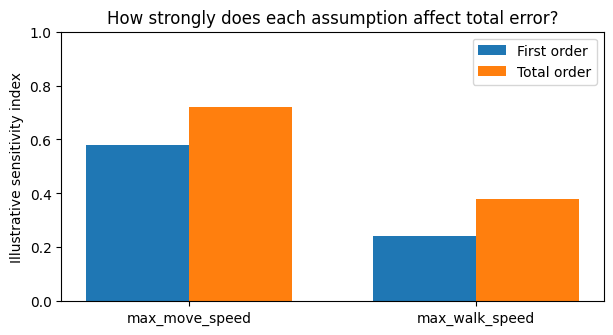

In [10]:
import matplotlib.pyplot as plt

names = ['max_move_speed', 'max_walk_speed']
first_order = [0.58, 0.24]
total_order = [0.72, 0.38]
x = range(len(names))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar([i - 0.18 for i in x], first_order, width=0.36, label='First order')
ax.bar([i + 0.18 for i in x], total_order, width=0.36, label='Total order')
ax.set_xticks(list(x), names)
ax.set_ylim(0, 1)
ax.set_ylabel('Illustrative sensitivity index')
ax.set_title('How strongly does each assumption affect total error?')
ax.legend()
plt.show()

### Discussion prompts

- Which parameter should receive better evidence or calibration first?
- What does the gap between first- and total-order indices suggest about interactions?
- Are replicas sufficiently consistent, or is stochastic noise dominating?
- Would changing the parameter ranges change the conclusion?

Sensitivity is conditional on the chosen model, parameter ranges, distributions, output quantity and simulation period. It is evidence about this experiment—not a universal ranking of FLEE parameters.

# 6. From localhost to ARCHER2

The scientific workflow should stay unchanged. The second-stage ARCHER2 work is to supply and validate machine-specific execution details:

- FabSim3 machine name, hostname, username and remote paths
- SLURM account, partition/QoS, wall time, nodes and tasks
- Python environment or modules containing FLEE and its dependencies
- data staging and result-fetch paths
- an MPI/launcher command appropriate to the allocation

After that configuration is tested, a local command such as `fabsim localhost flee_init_SA:...` becomes conceptually `fabsim archer2 flee_init_SA:...`. Do not present that substitution as verified until the ARCHER2 profile and a small smoke test have succeeded.

# Recap

- **FLEE** provides the migration model and the scientific question.
- **FabSim3** makes execution repeatable across local and HPC targets.
- **FabFly/FabFlee** contributes FLEE-specific tasks, ensembles, replicas and analysis hooks.
- **EasyVQ/EasyVVUQ** describes uncertainty, samples parameter combinations, encodes inputs, decodes outputs and computes sensitivity measures.

Together, they form one CVA/SEAVEA workflow: **design → automate → execute → aggregate → understand**.